# T2 Data access and profiling

**Goal T2.** Confirm access to the source tables, run EDA stage 1 (data quality) on each one and record grain, date range, row counts, null rates and gaps; then profile the activity of the sprint brand (activity per week, gaps between active days, GGR distribution), as the plan's domain EDA asks.

**Data.** The S3 S3 data lake (`org/40-gold`). This notebook reads **only local files**, no S3:

- the data-quality reports written by `make profile` (`eda/profile_tables.py`): `docs/dq_reports/{table}.json` (schema, rows, date range, gaps, key uniqueness, null rates, validation issues) and `semantic_checks_brand64.csv` (signals-table columns against the same quantity recomputed from the daily data);
- the local daily caches of `src/features/daily_cache.py` (activity and payments of brand 64).



In [1]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
REPORTS = PROJECT_ROOT / "docs/dq_reports"
CACHE = PROJECT_ROOT / "data/02_intermediate/daily_cache"
BRAND = 64
pd.set_option("display.max_colwidth", 90)

## 1. Source-table register

One row per source table: grain, date range, rows, columns, missing days, whether the key is unique, and how many validation issues the DQ suite found. Every check is a SQL aggregation over all the rows (no sample).

In [2]:
reports = {p.stem: json.loads(p.read_text()) for p in sorted(REPORTS.glob("gld_*.json"))}
register = pd.DataFrame([{
    "table": name, "from": r["date_range_start"], "to": r["date_range_end"], "rows": r["row_count"],
    "columns": len(r["columns"]), "gap_days": r["n_gap_days"],
    "key_unique": all(k["is_unique"] for k in r["key_checks"]) if r["key_checks"] else None,
    "issues": len(r["validation"]["issues"]), "grain": r["grain_description"],
} for name, r in reports.items()]).sort_values("rows", ascending=False)
register

,table,from,to,rows,columns,gap_days,key_unique,issues,grain
5,gld_player_signals_daily,2025-04-01,2026-10-06,689211331,165,0,True,5,"One row per player ever seen and as-of day (snapshot_date, UTC); the precomputed signa..."
1,gld_player_engagement_daily,2025-04-01,2026-10-06,688181493,24,0,True,0,"One row per player ever seen and day: sessions, bets and active day that day."
2,gld_player_financial_daily,2025-04-01,2026-10-06,688181082,18,0,True,1,"One row per player ever seen and day: EUR wagered, GGR, NGR, deposits, withdrawals tha..."
0,gld_player_bonus_daily,2025-04-01,2026-10-06,176426517,32,0,True,5,"One row per player, day, award type and currency with bonus activity that day (sparse)."
3,gld_player_gaming_daily,2025-04-01,2026-10-06,59644836,59,0,True,7,"One row per player, game, provider, day and currency with play that day (sparse)."
4,gld_player_payments_daily,2025-09-18,2026-10-06,5583579,31,40,True,2,"One row per player, processed day and currency with payments that day (sparse)."


Six daily tables from 2025-04-01 (payments from 2025-09-18) to 2026-10-06, keyed by (`tenant_id`, `player_id`), money in EUR. Every key is unique. The three player-day tables have about 689 M rows (one row per player ever seen and day); the event tables are sparse.

## 2. Null rates

Columns with any empty value, over all rows.

In [3]:
nulls = pd.DataFrame([{"table": name, "column": n["name"], "null_pct": n["null_percentage"]}
                      for name, r in reports.items() for n in r["null_stats"]])
nulls[nulls["null_pct"] > 0].sort_values("null_pct", ascending=False)

,table,column,null_pct
188,gld_player_signals_daily,brand_id,86.7789


Only one column has empty values: `brand_id` in `gld_player_signals_daily` (87%), empty before July 2026. The pipeline takes the brand from the activity table (`gld_player_gaming_daily`), which has it on every row.

## 3. Missing days and keys

In [4]:
for name, r in reports.items():
    if r["n_gap_days"]:
        gaps = pd.to_datetime(pd.Series(r["gap_dates"]))
        print(f"{name}: {r['n_gap_days']} missing days, by month:", gaps.dt.strftime("%Y-%m").value_counts().sort_index().to_dict())
pd.DataFrame([{"table": name, **k} for name, r in reports.items() for k in r["key_checks"]])[
    ["table", "column", "n_rows", "n_distinct", "is_unique"]]

gld_player_payments_daily: 40 missing days, by month: {'2025-09': 11, '2025-10': 21, '2025-11': 6, '2025-12': 2}


,table,column,n_rows,n_distinct,is_unique
0,gld_player_bonus_daily,tenant_id+brand_id+player_id+event_date+award_type+currency+source_system,176426517,176426517,True
1,gld_player_engagement_daily,tenant_id+player_id+snapshot_date,688181493,688181493,True
2,gld_player_financial_daily,tenant_id+player_id+snapshot_date,688181082,688181082,True
3,gld_player_gaming_daily,tenant_id+brand_id+player_id+game_id+provider_code+event_date+currency+source_system,59644836,59644836,True
4,gld_player_payments_daily,tenant_id+brand_id+player_id+event_date+currency+source_system,5583579,5583579,True
5,gld_player_signals_daily,tenant_id+player_id+snapshot_date,689211331,689211331,True


`gld_player_payments_daily` has no file on 40 days between September and December 2025. The other tables have a file every day.

## 4. Validation issues

What the DQ suite flagged (value ranges and referential integrity).

In [5]:
pd.DataFrame([{"table": name, **i} for name, r in reports.items() for i in r["validation"]["issues"]])

,table,column,check,message
0,gld_player_bonus_daily,bonus_cost,negative_value,"minimum -296.6000, on 2 day(s)"
1,gld_player_bonus_daily,bonus_cost_eur,negative_value,"minimum -296.6000, on 2 day(s)"
2,gld_player_bonus_daily,granted,negative_value,"minimum -296.6000, on 2 day(s)"
3,gld_player_bonus_daily,granted_eur,negative_value,"minimum -296.6000, on 2 day(s)"
4,gld_player_bonus_daily,player_id,referential_integrity,"90,079,817 player-days are missing from that day's gld_player_signals_daily"
5,gld_player_financial_daily,won_eur_today,negative_value,"minimum -207,773.6127, on 159 day(s)"
6,gld_player_gaming_daily,payout_eur,negative_value,"minimum -207,773.6126, on 193 day(s)"
7,gld_player_gaming_daily,won_playable_bonus,negative_value,"minimum -33,040.0000, on 169 day(s)"
8,gld_player_gaming_daily,won_playable_bonus_eur,negative_value,"minimum -747.2081, on 169 day(s)"
9,gld_player_gaming_daily,won_real,negative_value,"minimum -12,345,440.0000, on 155 day(s)"


- **Negative winnings** (`won_*`, `payout_eur`) on many days: reversals and corrections of earlier wins. They are kept: the GGR of a day nets them out.
- **Negative bonus amounts** on 2 days and a negative settlement time in payments: isolated, not used by the features.
- **Referential integrity**: player-days of the bonus and payments tables that are not in that day's signals table. Expected: the signals table only has players already seen, and a player can receive a bonus or pay before playing.

## 5. Semantic checks: do the signals-table columns mean what they say?

Each column of `gld_player_signals_daily` against the same quantity recomputed from the daily caches, for the brand's players with a bet in the 30 days up to each day (one day per month).

,median match share
column,
days_since_bet,0.160
active_days_l30d,0.984
active_days_l7d,0.995
ggr_eur_l30d,0.998
ggr_eur_l7d,1.000
wagered_eur_l30d,1.000
bets_l7d,1.000
bets_l30d,1.000
deposits_eur_l30d,1.000


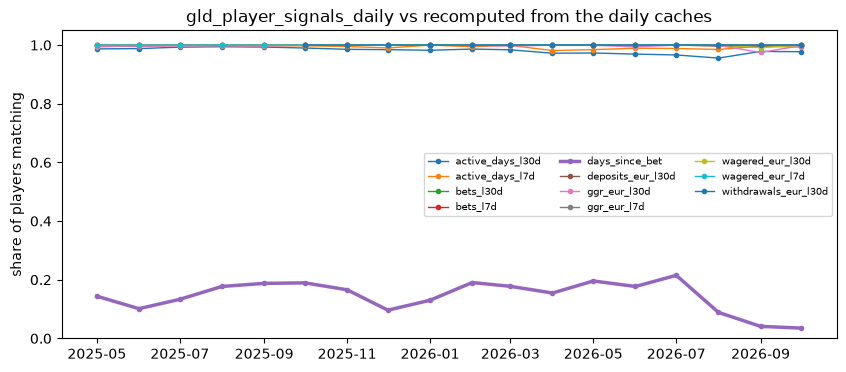

In [6]:
sem = pd.read_csv(REPORTS / f"semantic_checks_brand{BRAND}.csv", parse_dates=["day"])
match = sem.pivot_table(index="day", columns="column", values="match_share")
display(match.median().sort_values().round(3).rename("median match share").to_frame())
fig, ax = plt.subplots(figsize=(10, 4))
for col in match.columns:
    ax.plot(match.index, match[col], marker="o", ms=3, lw=2.5 if col == "days_since_bet" else 1, label=col)
ax.set_ylabel("share of players matching"); ax.set_ylim(0, 1.05)
ax.set_title("gld_player_signals_daily vs recomputed from the daily caches"); ax.legend(fontsize=7, ncol=3)
plt.show()

Activity and money windows match for 98% to 100% of the players. **`days_since_bet` matches for only 16%**: it is broken, so the features recompute recency from the activity (`days_since_last_bet`). `tenure_days` has a similar problem in the backfilled history (`docs/dq_reports/semantic_checks_brand64.md`), so the features use `days_since_first_bet`.

## 6. Deposit completeness

Players with a completed deposit over players with a bet, per month (payments cache).

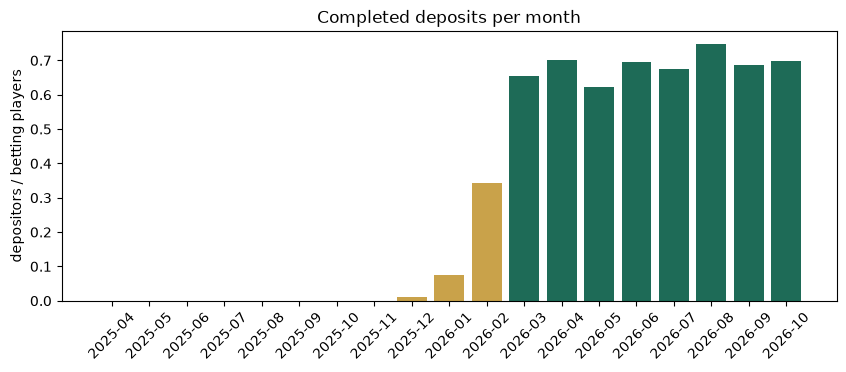

,month,betting_players,depositors,completed,failed,depositor_share
10,2025-04,30600,0.0,0.0,0.0,0.000
3,2025-05,35603,0.0,0.0,0.0,0.000
6,2025-06,27606,0.0,0.0,0.0,0.000
14,2025-07,19444,0.0,0.0,0.0,0.000
16,2025-08,18583,0.0,0.0,0.0,0.000
4,2025-09,19331,0.0,0.0,0.0,0.000
5,2025-10,22252,0.0,0.0,0.0,0.000
9,2025-11,17981,0.0,0.0,0.0,0.000
0,2025-12,14708,180.0,213.0,84249.0,0.012
11,2026-01,12115,925.0,1155.0,168677.0,0.076


In [7]:
pay = duckdb.sql(f"""
    SELECT strftime(day, '%Y-%m') AS month, COUNT(DISTINCT player_id) FILTER (WHERE deposit_count > 0) AS depositors,
           SUM(deposit_count) AS completed, SUM(failed_deposit_count) AS failed
    FROM read_parquet('{CACHE}/payments/brand{BRAND}/*.parquet', union_by_name=true) GROUP BY 1""").df()
act_m = duckdb.sql(f"""
    SELECT strftime(day, '%Y-%m') AS month, COUNT(DISTINCT player_id) AS betting_players
    FROM read_parquet('{CACHE}/activity/*.parquet') WHERE brand_id = {BRAND} GROUP BY 1""").df()
dep = act_m.merge(pay, on="month", how="left").fillna(0).sort_values("month")
dep["depositor_share"] = dep["depositors"] / dep["betting_players"]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(dep["month"], dep["depositor_share"], color=np.where(dep["month"] >= "2026-03", "#1e6b57", "#c9a24a"))
ax.set_ylabel("depositors / betting players"); ax.tick_params(axis="x", rotation=45)
ax.set_title("Completed deposits per month")
plt.show()
dep.round(3)

## 7. Activity profile (brand 64)

From the activity cache: one row per player and day with at least one bet.

1,640,224 player-days, 126,581 players, 2025-04-01 to 2026-10-06


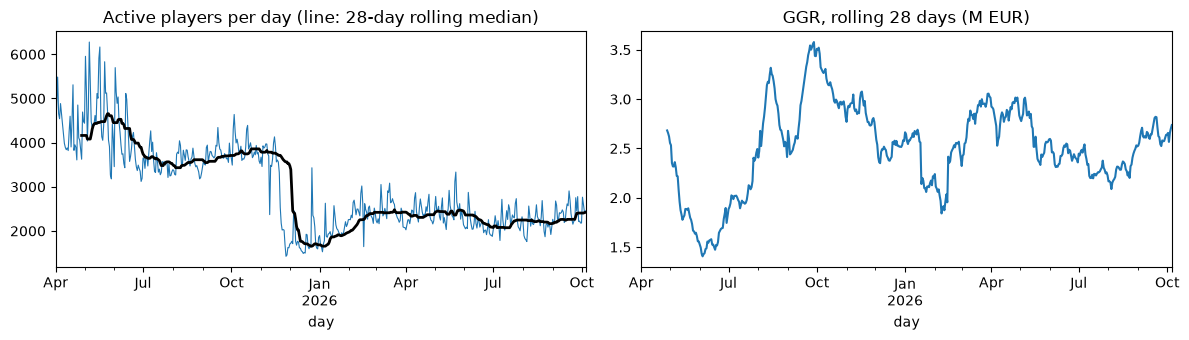

In [8]:
act = duckdb.sql(f"""SELECT player_id, day::DATE AS day, bets, turnover_eur, ggr_eur
    FROM read_parquet('{CACHE}/activity/*.parquet') WHERE brand_id = {BRAND}""").df()
act["day"] = pd.to_datetime(act["day"])
print(f"{len(act):,} player-days, {act['player_id'].nunique():,} players, {act['day'].min().date()} to {act['day'].max().date()}")
daily = act.groupby("day").agg(players=("player_id", "size"), ggr_eur=("ggr_eur", "sum"))
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
daily["players"].plot(ax=axes[0], lw=0.8); daily["players"].rolling(28).median().plot(ax=axes[0], lw=2, color="black")
axes[0].set_title("Active players per day (line: 28-day rolling median)")
(daily["ggr_eur"].rolling(28).sum() / 1e6).plot(ax=axes[1]); axes[1].set_title("GGR, rolling 28 days (M EUR)")
plt.tight_layout(); plt.show()

### Activity per player and week

,share of player-weeks
days,
1,0.449
2,0.195
3,0.108
4,0.079
5,0.061
6,0.052
7,0.056


,count,mean,std,min,25%,50%,75%,90%,99%,max
bets,658395.0,1493.0,3702.0,1.0,76.0,328.0,1262.0,3737.0,17668.0,195316.0


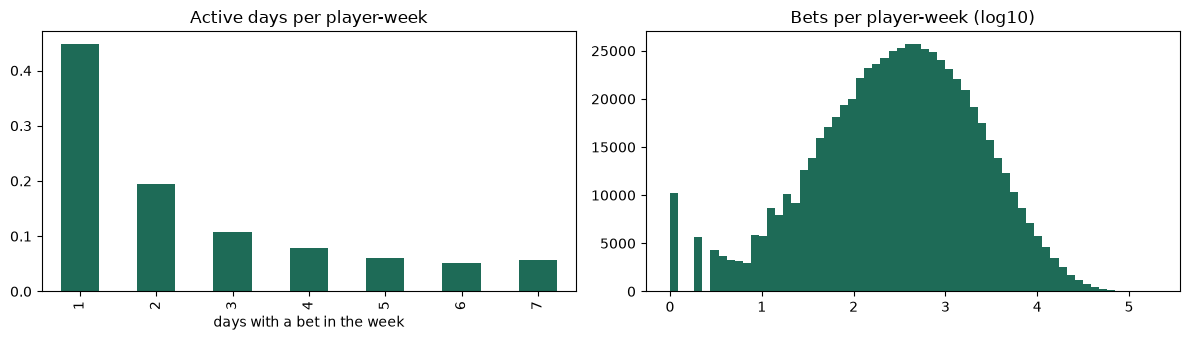

In [9]:
act["week"] = act["day"].dt.to_period("W")
weekly = act.groupby(["player_id", "week"]).agg(days=("day", "size"), bets=("bets", "sum"))
display(weekly["days"].value_counts(normalize=True).sort_index().round(3).rename("share of player-weeks").to_frame())
display(weekly["bets"].describe(percentiles=[.25, .5, .75, .9, .99]).round(0).to_frame().T)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
weekly["days"].value_counts(normalize=True).sort_index().plot.bar(ax=axes[0], color="#1e6b57")
axes[0].set_title("Active days per player-week"); axes[0].set_xlabel("days with a bet in the week")
axes[1].hist(np.log10(weekly["bets"]), bins=60, color="#1e6b57"); axes[1].set_title("Bets per player-week (log10)")
plt.tight_layout(); plt.show()

In a week with any play, 45% of the players bet on a single day and only 6% on all 7. The number of bets is very skewed: median 328 per player-week, 90th percentile 3,737, 99th 17,668.

### Gaps between active days

Silent days between two consecutive active days of a player: the raw material of the churn definition (T3).

,share of gaps
>= 1 days,0.3843
>= 7 days,0.1421
>= 14 days,0.0830
>= 30 days,0.0401
>= 60 days,0.0217


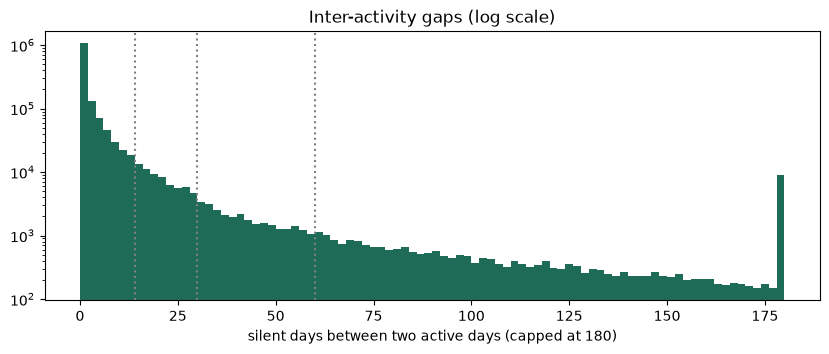

In [10]:
a = act.sort_values(["player_id", "day"])
gap = (a.groupby("player_id")["day"].diff().dt.days - 1).dropna()
display(pd.Series({f">= {n} days": (gap >= n).mean() for n in (1, 7, 14, 30, 60)}).round(4).rename("share of gaps").to_frame())
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(gap.clip(upper=180), bins=90, color="#1e6b57", log=True)
for n in (14, 30, 60):
    ax.axvline(n, color="grey", ls=":")
ax.set_xlabel("silent days between two active days (capped at 180)"); ax.set_title("Inter-activity gaps (log scale)")
plt.show()

Most returns are immediate (median gap 0: the next day), 14% of the gaps last a week or more, 4% a month or more and 2% two months or more. A gap long enough to be called churn is rare among players who do come back, which is why the threshold choice of T3 is a trade-off between false churns and late labels.

### GGR distribution

,value
player-months,331523.0000
zero GGR,0.0003
negative (the player won),0.1443
median EUR,11.3259
p90 EUR,377.7602
p99 EUR,3113.3351
max EUR,173684.2848
share of positive GGR from the top 10%,0.7883
share of positive GGR from the top 1%,0.3777


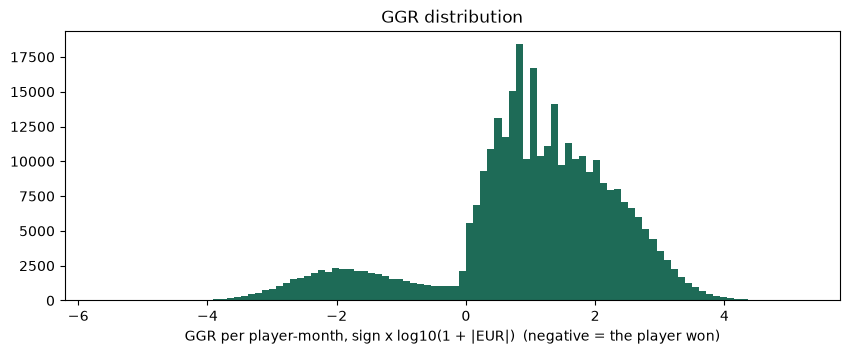

In [11]:
pm = act.assign(month=act["day"].dt.to_period("M")).groupby(["player_id", "month"])["ggr_eur"].sum()
pos = pm[pm > 0].sort_values(ascending=False)
display(pd.Series({
    "player-months": len(pm), "zero GGR": (pm == 0).mean(), "negative (the player won)": (pm < 0).mean(),
    "median EUR": pm.median(), "p90 EUR": pm.quantile(.9), "p99 EUR": pm.quantile(.99), "max EUR": pm.max(),
    "share of positive GGR from the top 10%": pos.head(int(len(pos) * .1)).sum() / pos.sum(),
    "share of positive GGR from the top 1%": pos.head(int(len(pos) * .01)).sum() / pos.sum(),
}).round(4).rename("value").to_frame())
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(np.sign(pm) * np.log10(1 + pm.abs()), bins=100, color="#1e6b57")
ax.set_xlabel("GGR per player-month, sign x log10(1 + |EUR|)  (negative = the player won)"); ax.set_title("GGR distribution")
plt.show()

GGR per player and month is heavy-tailed: almost never exactly 0, negative in 14% of the player-months (the player won), median 11 EUR, 99th percentile about 3,100 EUR. The top 10% of the positive player-months bring 79% of the GGR and the top 1% bring 38%. That is why the monetary features are winsorised at the 99.5th percentile (flagged, never deleted, `eda/anomalies.py`) and sign-log scaled, and why the targeting replay ranks by value at risk.

## 8. Findings

1. **Access and grain confirmed**: six daily source tables, 18 months, unique keys, money in EUR.
2. **`days_since_bet` and `tenure_days` in the signals table are broken**: recency and tenure are recomputed from the activity.
3. **Completed deposits are missing before March 2026**: deposit features are empty before then; question open with the data team.
4. **`brand_id` is empty in the signals table before July 2026** and **payments miss 40 days in late 2025**: the brand comes from the activity table, and the payments gap is covered by the deposit masking.
5. **Activity is bursty and value is concentrated**: most weeks have a single active day, and 10% of the player-months bring 79% of the GGR.
